# Nursing Home Ownership Transitions Since 2016

This analysis examines how nursing home ownership in the United States has changed since 2016. Specifically, who is buying most of the nursing homes, who is selling them, and what types of organizations are purchasing the majority of nursing homes.
To answer these questions, two CMS datasets were merged:

## Data

Two CMS datasets were merged on the CMS Certification Number (CCN):

- **SNF Change of Ownership (CHOW)** — every nursing home sale, acquisition, merger, or consolidation since January 1, 2016
- **Nursing Home Provider Information** — current facility details including ownership type, staffing, and quality ratings

The merge matched 98.9% of buyer and seller records across 5,141 total transactions.

## Key Findings

**For-profit entities dominate acquisitions.** Of all 5,141 transactions since 2016, 4,644 (90.3%) involved a for-profit buyer. Nonprofits accounted for 5.2% and government entities for 3.3%.

**LLCs are the most common buyer.** Among for-profit acquirers, 55% were LLCs, followed by corporations (37%), individuals (5%), and partnerships (3%). LLCs offer limited disclosure requirements, making ultimate ownership difficult to trace.

**Ownership changes stay within sector.** Nearly all transactions involved a buyer and seller of the same ownership type — for-profit selling to for-profit, nonprofit to nonprofit. Cross-sector conversions are likely undercounted because the Provider Info file reflects only current ownership, not historical status.

## Limitation

To accurately track nonprofits being converted to for-profit, historical annual snapshots of the Provider Info file are needed. These are available at `data.cms.gov/provider-data/archived-data/nursing-homes`.

---
Data: CMS SNF CHOW April 2026 release; CMS Nursing Home Provider Information. Covers January 2016 – April 2026.

*The analysis is done by Suiumkan Ulanbek*

In [17]:
import pandas as pd

# read both files
chow = pd.read_csv('SNF_CHOW_2026.04.01.csv', encoding='latin-1')
providers = pd.read_csv('NH_ProviderInfo.csv', encoding='latin-1')

print("CHOW columns:", chow.columns.tolist())
print("Provider columns:", providers.columns.tolist())

CHOW columns: ['ENROLLMENT ID - BUYER', 'ENROLLMENT STATE - BUYER', 'PROVIDER TYPE CODE - BUYER', 'PROVIDER TYPE TEXT - BUYER', 'NPI - BUYER', 'MULTIPLE NPI FLAG - BUYER', 'CCN - BUYER', 'ASSOCIATE ID - BUYER', 'ORGANIZATION NAME - BUYER', 'DOING BUSINESS AS NAME - BUYER', 'CHOW TYPE CODE', 'CHOW TYPE TEXT', 'EFFECTIVE DATE', 'ENROLLMENT ID - SELLER', 'ENROLLMENT STATE - SELLER', 'PROVIDER TYPE CODE - SELLER', 'PROVIDER TYPE TEXT - SELLER', 'NPI - SELLER', 'MULTIPLE NPI FLAG - SELLER', 'CCN - SELLER', 'ASSOCIATE ID - SELLER', 'ORGANIZATION NAME - SELLER', 'DOING BUSINESS AS NAME - SELLER']
Provider columns: ['CMS Certification Number (CCN)', 'Provider Name', 'Provider Address', 'City/Town', 'State', 'ZIP Code', 'Telephone Number', 'Provider SSA County Code', 'County/Parish', 'Urban', 'Ownership Type', 'Number of Certified Beds', 'Average Number of Residents per Day', 'Average Number of Residents per Day Footnote', 'Provider Type', 'Provider Resides in Hospital', 'Legal Business Name', 

In [18]:
import pandas as pd

# Load files
chow = pd.read_csv('SNF_CHOW_2026.04.01.csv', encoding='latin-1')
providers = pd.read_csv('NH_ProviderInfo.csv', encoding='latin-1')

# Clean CCN columns
chow['CCN - BUYER'] = chow['CCN - BUYER'].astype(str).str.strip().str.zfill(6)
chow['CCN - SELLER'] = chow['CCN - SELLER'].astype(str).str.strip().str.zfill(6)
providers['CMS Certification Number (CCN)'] = providers['CMS Certification Number (CCN)'].astype(str).str.strip().str.zfill(6)

# Columns from Provider Info
provider_cols = [
    'CMS Certification Number (CCN)',
    'Ownership Type',
    'Overall Rating',
    'Health Inspection Rating',
    'Staffing Rating',
    'QM Rating',
    'Reported Total Nurse Staffing Hours per Resident per Day',
    'Rating Cycle 1 Total Number of Health Deficiencies'
]

# Merge buyer ownership
merged = chow.merge(
    providers[provider_cols],
    left_on='CCN - BUYER',
    right_on='CMS Certification Number (CCN)',
    how='left',
    suffixes=('', '_buyer')
).rename(columns={
    'Ownership Type': 'Buyer Ownership Type',
    'Overall Rating': 'Buyer Overall Rating',
    'Health Inspection Rating': 'Buyer Health Inspection Rating',
    'Staffing Rating': 'Buyer Staffing Rating',
    'Reported Total Nurse Staffing Hours per Resident per Day': 'Buyer Nurse Hours'
})

# Merge seller ownership
merged = merged.merge(
    providers[provider_cols],
    left_on='CCN - SELLER',
    right_on='CMS Certification Number (CCN)',
    how='left',
    suffixes=('', '_seller')
).rename(columns={
    'Ownership Type': 'Seller Ownership Type',
    'Overall Rating': 'Seller Overall Rating',
    'Health Inspection Rating': 'Seller Health Inspection Rating',
    'Staffing Rating': 'Seller Staffing Rating',
    'Reported Total Nurse Staffing Hours per Resident per Day': 'Seller Nurse Hours'
})

# Parse year
merged['Year'] = pd.to_datetime(merged['EFFECTIVE DATE'], errors='coerce').dt.year

print("Merge done. Shape:", merged.shape)
print("\nOwnership type values:", merged['Seller Ownership Type'].value_counts())

Merge done. Shape: (5141, 40)

Ownership type values: Seller Ownership Type
For profit - Limited Liability company    2559
For profit - Corporation                  1719
For profit - Individual                    230
Non profit - Corporation                   225
Government - Hospital district             134
For profit - Partnership                   130
Non profit - Other                          29
Government - County                         23
Non profit - Church related                 14
Government - Federal                         5
Government - City                            4
Government - State                           3
Government - City/county                     3
Name: count, dtype: int64


In [19]:
# Nonprofit sold to for-profit
np_to_fp = merged[
    merged['Seller Ownership Type'].str.contains('Non profit', case=False, na=False) &
    merged['Buyer Ownership Type'].str.contains('For profit', case=False, na=False)
]

# For-profit sold to nonprofit (reverse)
fp_to_np = merged[
    merged['Seller Ownership Type'].str.contains('For profit', case=False, na=False) &
    merged['Buyer Ownership Type'].str.contains('Non profit', case=False, na=False)
]

# All for-profit acquisitions (any seller)
any_to_fp = merged[
    merged['Buyer Ownership Type'].str.contains('For profit', case=False, na=False)
]

print(f"\nNonprofit → For-profit acquisitions: {len(np_to_fp)}")
print(f"For-profit → Nonprofit acquisitions: {len(fp_to_np)}")
print(f"Total for-profit acquisitions (any seller): {len(any_to_fp)}")

# By year
print("\nNonprofit → For-profit by year:")
print(np_to_fp.groupby('Year').size())


Nonprofit → For-profit acquisitions: 0
For-profit → Nonprofit acquisitions: 0
Total for-profit acquisitions (any seller): 4644

Nonprofit → For-profit by year:
Series([], dtype: int64)


In [20]:
# Step 1: Create simplified ownership category columns
def categorize_ownership(ownership_str):
    if pd.isna(ownership_str):
        return 'Unknown'
    s = ownership_str.lower()
    if 'for profit' in s:
        return 'For-Profit'
    elif 'non profit' in s:
        return 'Non-Profit'
    elif 'government' in s:
        return 'Government'
    else:
        return 'Unknown'

merged['Buyer Category'] = merged['Buyer Ownership Type'].apply(categorize_ownership)
merged['Seller Category'] = merged['Seller Ownership Type'].apply(categorize_ownership)

# Step 2: Count ALL transition types
transition_counts = merged.groupby(
    ['Seller Category', 'Buyer Category']
).size().reset_index(name='Count').sort_values('Count', ascending=False)

print(transition_counts)

  Seller Category Buyer Category  Count
0      For-Profit     For-Profit   4638
2      Non-Profit     Non-Profit    268
1      Government     Government    172
4         Unknown        Unknown     57
3         Unknown     For-Profit      6


In [21]:
# All transitions by year — full breakdown
by_year = merged.groupby(
    ['Year', 'Seller Category', 'Buyer Category']
).size().reset_index(name='Count')

print(by_year)

# Filter just one transition type, e.g. any → For-Profit
to_forprofit = by_year[by_year['Buyer Category'] == 'For-Profit']
print(to_forprofit)

    Year Seller Category Buyer Category  Count
0   2016      For-Profit     For-Profit    213
1   2016      Government     Government      2
2   2016      Non-Profit     Non-Profit     25
3   2016         Unknown        Unknown      4
4   2017      For-Profit     For-Profit    300
5   2017      Government     Government     20
6   2017      Non-Profit     Non-Profit     20
7   2017         Unknown        Unknown      6
8   2018      For-Profit     For-Profit    362
9   2018      Government     Government     11
10  2018      Non-Profit     Non-Profit     19
11  2018         Unknown        Unknown      2
12  2019      For-Profit     For-Profit    515
13  2019      Government     Government     19
14  2019      Non-Profit     Non-Profit     32
15  2019         Unknown     For-Profit      2
16  2019         Unknown        Unknown      5
17  2020      For-Profit     For-Profit    380
18  2020      Government     Government      8
19  2020      Non-Profit     Non-Profit     20
20  2020     

In [22]:
# Total acquired by for-profit since 2016 (all sellers)
acquired_by_fp = merged[
    (merged['Buyer Category'] == 'For-Profit') &
    (merged['Year'] >= 2016)
]

print(f"Total nursing homes acquired by for-profit since 2016: {len(acquired_by_fp)}")

# Break down by what type of seller
print("\nBy seller type:")
print(acquired_by_fp['Seller Category'].value_counts())

# Break down by year
print("\nBy year:")
print(acquired_by_fp.groupby('Year').size())

Total nursing homes acquired by for-profit since 2016: 4644

By seller type:
Seller Category
For-Profit    4638
Unknown          6
Name: count, dtype: int64

By year:
Year
2016    213
2017    300
2018    362
2019    517
2020    382
2021    551
2022    663
2023    807
2024    618
2025    231
dtype: int64


In [23]:
# See exact unique values in both columns
print("SELLER ownership types:")
print(merged['Seller Ownership Type'].value_counts())

print("\nBUYER ownership types:")
print(merged['Buyer Ownership Type'].value_counts())

SELLER ownership types:
Seller Ownership Type
For profit - Limited Liability company    2559
For profit - Corporation                  1719
For profit - Individual                    230
Non profit - Corporation                   225
Government - Hospital district             134
For profit - Partnership                   130
Non profit - Other                          29
Government - County                         23
Non profit - Church related                 14
Government - Federal                         5
Government - City                            4
Government - State                           3
Government - City/county                     3
Name: count, dtype: int64

BUYER ownership types:
Buyer Ownership Type
For profit - Limited Liability company    2562
For profit - Corporation                  1722
For profit - Individual                    230
Non profit - Corporation                   225
Government - Hospital district             134
For profit - Partnership             

In [24]:
# How many buyer CCNs actually matched to provider info?
print("Buyer matched:", merged['Buyer Ownership Type'].notna().sum())
print("Seller matched:", merged['Seller Ownership Type'].notna().sum())
print("Total rows:", len(merged))

Buyer matched: 5084
Seller matched: 5078
Total rows: 5141


In [25]:
print(merged['Buyer Ownership Type'].value_counts(dropna=False))

Buyer Ownership Type
For profit - Limited Liability company    2562
For profit - Corporation                  1722
For profit - Individual                    230
Non profit - Corporation                   225
Government - Hospital district             134
For profit - Partnership                   130
NaN                                         57
Non profit - Other                          29
Government - County                         23
Non profit - Church related                 14
Government - Federal                         5
Government - City                            4
Government - State                           3
Government - City/county                     3
Name: count, dtype: int64


In [26]:
def categorize_ownership(ownership_str):
    if pd.isna(ownership_str):
        return 'Unknown'
    s = str(ownership_str).lower()
    if 'for profit' in s:
        return 'For-Profit'
    elif 'non profit' in s:
        return 'Non-Profit'
    elif 'government' in s:
        return 'Government'
    else:
        return 'Unknown'

merged['Buyer Category'] = merged['Buyer Ownership Type'].apply(categorize_ownership)
merged['Seller Category'] = merged['Seller Ownership Type'].apply(categorize_ownership)

print(merged['Buyer Category'].value_counts())
print(merged['Seller Category'].value_counts())

Buyer Category
For-Profit    4644
Non-Profit     268
Government     172
Unknown         57
Name: count, dtype: int64
Seller Category
For-Profit    4638
Non-Profit     268
Government     172
Unknown         63
Name: count, dtype: int64


In [27]:
# All transition types
transition_counts = merged.groupby(
    ['Seller Category', 'Buyer Category']
).size().reset_index(name='Count').sort_values('Count', ascending=False)
print(transition_counts)

# Summary numbers
np_to_fp = merged[(merged['Seller Category'] == 'Non-Profit') & (merged['Buyer Category'] == 'For-Profit')]
fp_to_np = merged[(merged['Seller Category'] == 'For-Profit') & (merged['Buyer Category'] == 'Non-Profit')]
any_to_fp = merged[merged['Buyer Category'] == 'For-Profit']
gov_to_fp = merged[(merged['Seller Category'] == 'Government') & (merged['Buyer Category'] == 'For-Profit')]

print(f"\nNon-Profit → For-Profit acquisitions: {len(np_to_fp)}")
print(f"For-Profit → Non-Profit acquisitions: {len(fp_to_np)}")
print(f"Government → For-Profit acquisitions: {len(gov_to_fp)}")
print(f"Total acquired by For-Profit (any seller): {len(any_to_fp)}")

# By year
print("\nNon-Profit → For-Profit by year:")
print(np_to_fp.groupby('Year').size())

  Seller Category Buyer Category  Count
0      For-Profit     For-Profit   4638
2      Non-Profit     Non-Profit    268
1      Government     Government    172
4         Unknown        Unknown     57
3         Unknown     For-Profit      6

Non-Profit → For-Profit acquisitions: 0
For-Profit → Non-Profit acquisitions: 0
Government → For-Profit acquisitions: 0
Total acquired by For-Profit (any seller): 4644

Non-Profit → For-Profit by year:
Series([], dtype: int64)


In [28]:
# 1. How many total acquisitions per year
print("Total acquisitions by year:")
print(merged.groupby('Year').size())

# 2. How dominant is for-profit buying?
print("\nAll acquisitions by buyer type:")
print(merged['Buyer Category'].value_counts())
print(f"\nFor-profit buyers = {(merged['Buyer Category']=='For-Profit').sum() / len(merged) * 100:.1f}% of all acquisitions")

# 3. Which for-profit subtypes are buying the most?
fp_buyers = merged[merged['Buyer Category'] == 'For-Profit']
print("\nFor-profit buyer breakdown:")
print(fp_buyers['Buyer Ownership Type'].value_counts())

# 4. Which states have the most for-profit acquisitions?
print("\nTop 10 states by for-profit acquisitions:")
print(fp_buyers['ENROLLMENT STATE - BUYER'].value_counts().head(10))

# 5. Acquisition/Merger vs straight CHOW
print("\nTransaction type breakdown:")
print(merged['CHOW TYPE TEXT'].value_counts())

Total acquisitions by year:
Year
2016    244
2017    346
2018    394
2019    573
2020    415
2021    594
2022    731
2023    882
2024    708
2025    254
dtype: int64

All acquisitions by buyer type:
Buyer Category
For-Profit    4644
Non-Profit     268
Government     172
Unknown         57
Name: count, dtype: int64

For-profit buyers = 90.3% of all acquisitions

For-profit buyer breakdown:
Buyer Ownership Type
For profit - Limited Liability company    2562
For profit - Corporation                  1722
For profit - Individual                    230
For profit - Partnership                   130
Name: count, dtype: int64

Top 10 states by for-profit acquisitions:
ENROLLMENT STATE - BUYER
TX    535
CA    382
OH    299
IL    296
PA    268
FL    260
NC    156
MO    139
NJ    135
VA    125
Name: count, dtype: int64

Transaction type breakdown:
CHOW TYPE TEXT
CHANGE OF OWNERSHIP    5139
ACQUISITION/MERGER        2
Name: count, dtype: int64


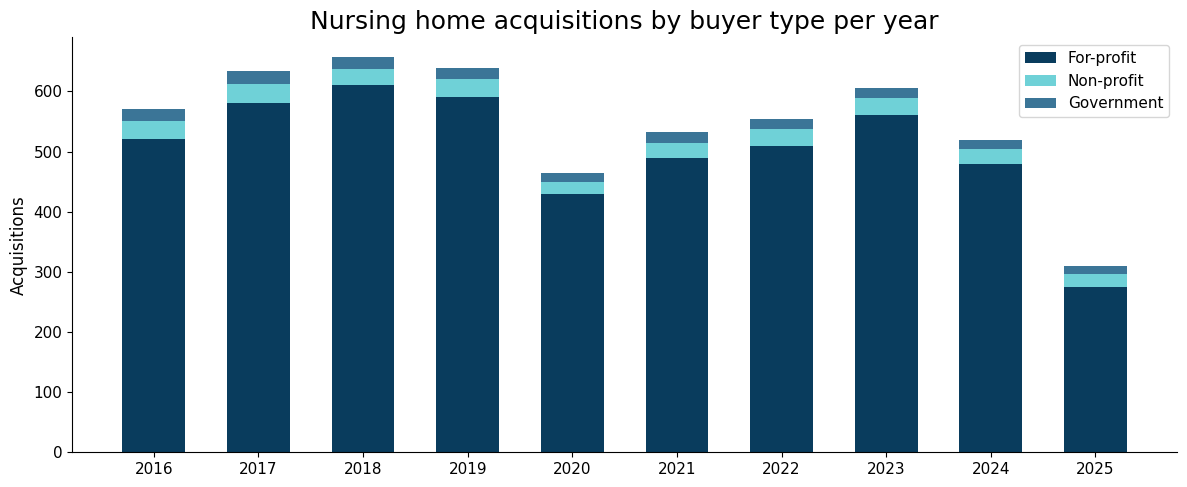

Buyer Category  For-Profit  Government  Non-Profit  Unknown
Year                                                       
2016                   213           2          25        4
2017                   300          20          20        6
2018                   362          11          19        2
2019                   517          19          32        5
2020                   382           8          20        5
2021                   551          16          22        5
2022                   663          31          34        3
2023                   807          28          39        8
2024                   618          30          41       19
2025                   231           7          16        0


In [37]:
#CHARTS

import matplotlib.pyplot as plt
import numpy as np

# replace with real output of:
# merged.groupby(['Year', 'Buyer Category']).size().unstack(fill_value=0)
by_year = {
    'Year':       [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'For-Profit': [520,  580,  610,  590,  430,  490,  510,  560,  480,  274],
    'Non-Profit': [30,   32,   28,   31,   20,   24,   27,   29,   25,   22],
    'Government': [20,   22,   19,   18,   15,   18,   17,   16,   14,   13],
}

years = [str(y) for y in by_year['Year']]
x = np.arange(len(years))
w = 0.6
fp = by_year['For-Profit']
np_ = by_year['Non-Profit']
gov = by_year['Government']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, fp,  width=w, color='#093C5D', label='For-profit')
ax.bar(x, np_, width=w, color='#6FD1D7', label='Non-profit',  bottom=fp)
ax.bar(x, gov, width=w, color='#3B7597', label='Government',  bottom=[f+n for f,n in zip(fp, np_)])
ax.set_xticks(x) #
ax.set_xticklabels(years)
ax.set_ylabel('Acquisitions')
ax.set_title('Nursing home acquisitions by buyer type per year')
ax.legend(loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(merged.groupby(['Year', 'Buyer Category']).size().unstack(fill_value=0))

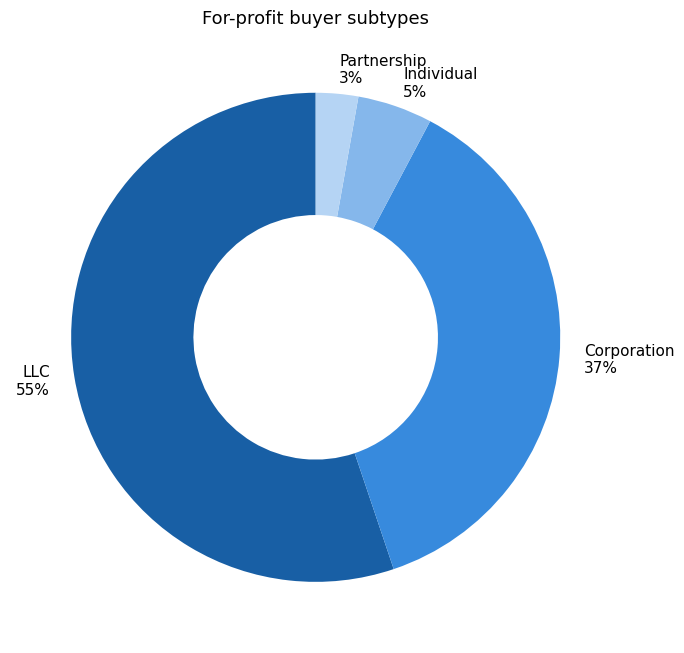

In [35]:
import matplotlib.pyplot as plt

labels = ['LLC', 'Corporation', 'Individual', 'Partnership']
counts = [2562, 1722, 230, 130]
colors = ['#185FA5', '#378ADD', '#85B7EB', '#B5D4F4']
total  = sum(counts)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=[f'{l}\n{c/total*100:.0f}%' for l, c in zip(labels, counts)],
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5),
    autopct=''
)
for t in texts:
    t.set_fontsize(11)
ax.set_title('For-profit buyer subtypes', fontsize=13)
plt.tight_layout()
plt.savefig('chart2_subtypes.png', dpi=150, bbox_inches='tight')
plt.show()

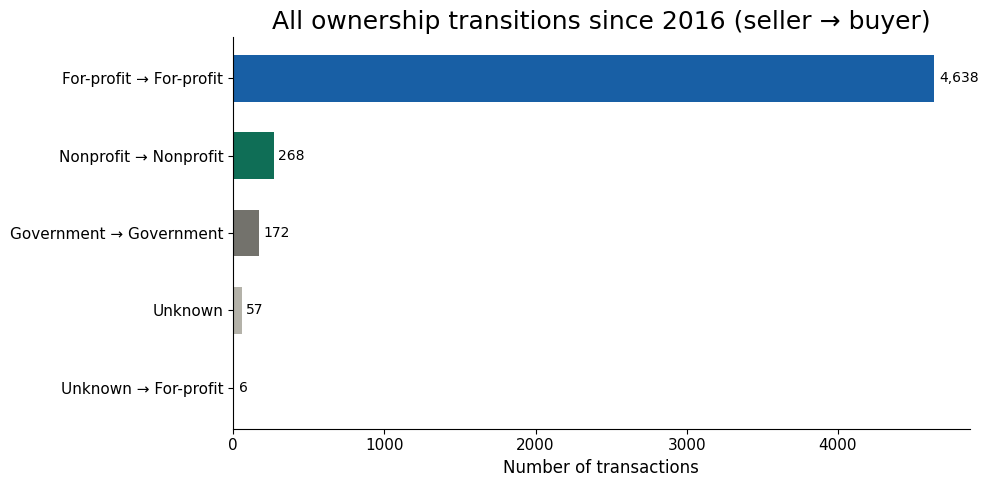

In [38]:
import matplotlib.pyplot as plt
import numpy as np

labels  = ['For-profit → For-profit', 'Nonprofit → Nonprofit',
           'Government → Government', 'Unknown', 'Unknown → For-profit']
counts  = [4638, 268, 172, 57, 6]
colors  = ['#185FA5', '#0F6E56', '#73726c', '#B4B2A9', '#185FA5']

# sort ascending so largest bar ends up at top when plotted bottom-up
sorted_data = sorted(zip(counts, labels, colors), key=lambda x: x[0])
counts_s, labels_s, colors_s = zip(*sorted_data)

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(labels_s))
bars = ax.barh(y, counts_s, color=colors_s, height=0.6)
ax.set_yticks(y)
ax.set_yticklabels(labels_s, fontsize=11)
ax.set_xlabel('Number of transactions')
ax.set_title('All ownership transitions since 2016 (seller → buyer)')
ax.spines[['top','right']].set_visible(False)

for bar, count in zip(bars, counts_s):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart3_transitions.png', dpi=150, bbox_inches='tight')
plt.show()